Ridge and Lasso is mainly used to handle overfitting condition in linear regression. Lambda (hyperparameter) is mainly given as Alpha in sklearn. (Alpha = 0 is mainly linear regression). It is multiplied by slope^2 in Ridge(L2 regularization) and by |slope| in lasso(L1 regularization). 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing 

In [ ]:
house_data=fetch_california_housing()

In [ ]:
dataset = pd.DataFrame(house_data.data) 

In [ ]:
x=house_data.data                         
y=house_data.target

In [ ]:
x

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split                        # Train test split

# Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

GridSearchCV is a tool that automatically tries multiple combinations of hyperparameters for your model and finds the best one using cross-validation.
Why Use GridSearchCV with Ridge/Lasso?
Both Ridge and Lasso have a key hyperparameter alpha (regularization strength) that controls how much the model is penalized for large coefficients.

Small alpha = Less regularization (closer to linear regression)

Large alpha = More regularization (simpler model, less overfitting)

GridSearchCV helps find the optimal alpha value automatically!



In [ ]:
ridge_regressor=Ridge()
ridge_regressor

In [ ]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train, y_train)

In [ ]:
print (ridgecv.best_params_)

In [ ]:
print(ridgecv.best_score_)

In [ ]:
print(ridgecv)

In [ ]:
ridge_predict = ridgecv.predict(x_test)

In [ ]:
ridge_predict

In [ ]:
import seaborn as sns
sns.displot(ridge_predict - y_test)

In [ ]:
sns.displot(ridge_predict - y_test, kind='kde')

In [ ]:
from sklearn.metrics import r2_score

score = r2_score(ridge_predict,y_test)
score

In [43]:
# Lasso Regression

from sklearn.linear_model import Lasso

In [44]:
lasso = Lasso()

In [45]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalu

In [46]:
print (lassocv.best_params_)

{'alpha': 1}


In [47]:
print(ridgecv.best_score_)

-0.5192548258531768


In [48]:
lasso_predict = lassocv.predict(x_test)

In [49]:
lasso_predict

array([1.72559335, 1.87880366, 2.14751489, ..., 2.8426924 , 1.95352989,
       1.95475031], shape=(4128,))

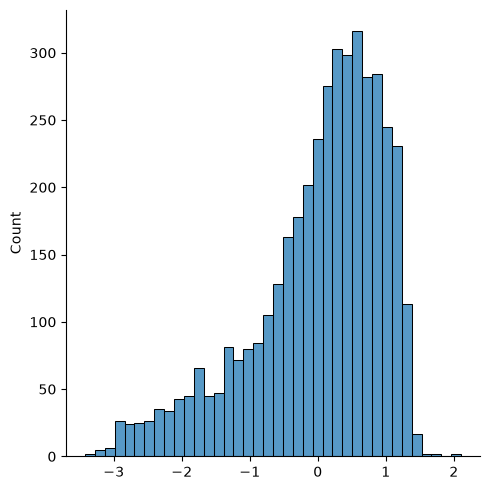

In [50]:
sns.displot(lasso_predict - y_test)

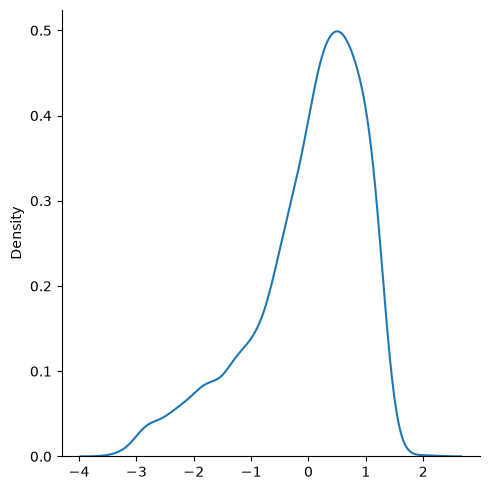

In [52]:
sns.displot(lasso_predict - y_test, kind='kde')

In [53]:
score = r2_score(lasso_predict,y_test)
score

-10.872679150567302